# Initialization

## Package Imports

In [ ]:
import sklearn
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

from tabulate import tabulate

import warnings
from sklearn.exceptions import ConvergenceWarning

## Mount Drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Constants

In [ ]:
SEED = 102800

## Error Handling

In [ ]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Data Set Import

In [ ]:
dirPath = "/content/drive/MyDrive/CSCI-B 556: Applied ML/B556_Raw_Data/Breast_Cancer/"
cancer_data = pd.read_csv(dirPath + "breast-cancer.csv")

In [ ]:
cancer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
cancer_labels = LabelEncoder().fit_transform(cancer_data["diagnosis"])
cancer_data = cancer_data.drop(columns=["diagnosis", "id"])

# Preface

Originally, I did this using the possums dataset which I used in the previous homework. However, that was resulting in perfect models (RMSE of 0.0) in classifying which population a possum came from. I presume this is because the dataset itself is relatively small. So, I am redoing this with a breast cancer diagnosis dataset.

# Part 1
Display the statistical values for each of the attributes, along with visualizations (e.g., histogram) of the distributions for each attribute. Are there any attributes that might require special treatment? If so, what special treatment might they require? [2 points]

In [ ]:
cancer_data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
cancer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

In [ ]:
def plot_histograms(data):
  fig, axes = plt.subplots(6, 5, figsize=(16, 12))  # larger figure
  axes = axes.flatten()

  for i, col in enumerate(data.columns):
      data[col].hist(ax=axes[i])
      axes[i].set_title(col, fontsize=8)

  # Add spacing
  plt.subplots_adjust(hspace=0.6, wspace=0.4)  # vertical & horizontal spacing
  plt.tight_layout()
  plt.show()

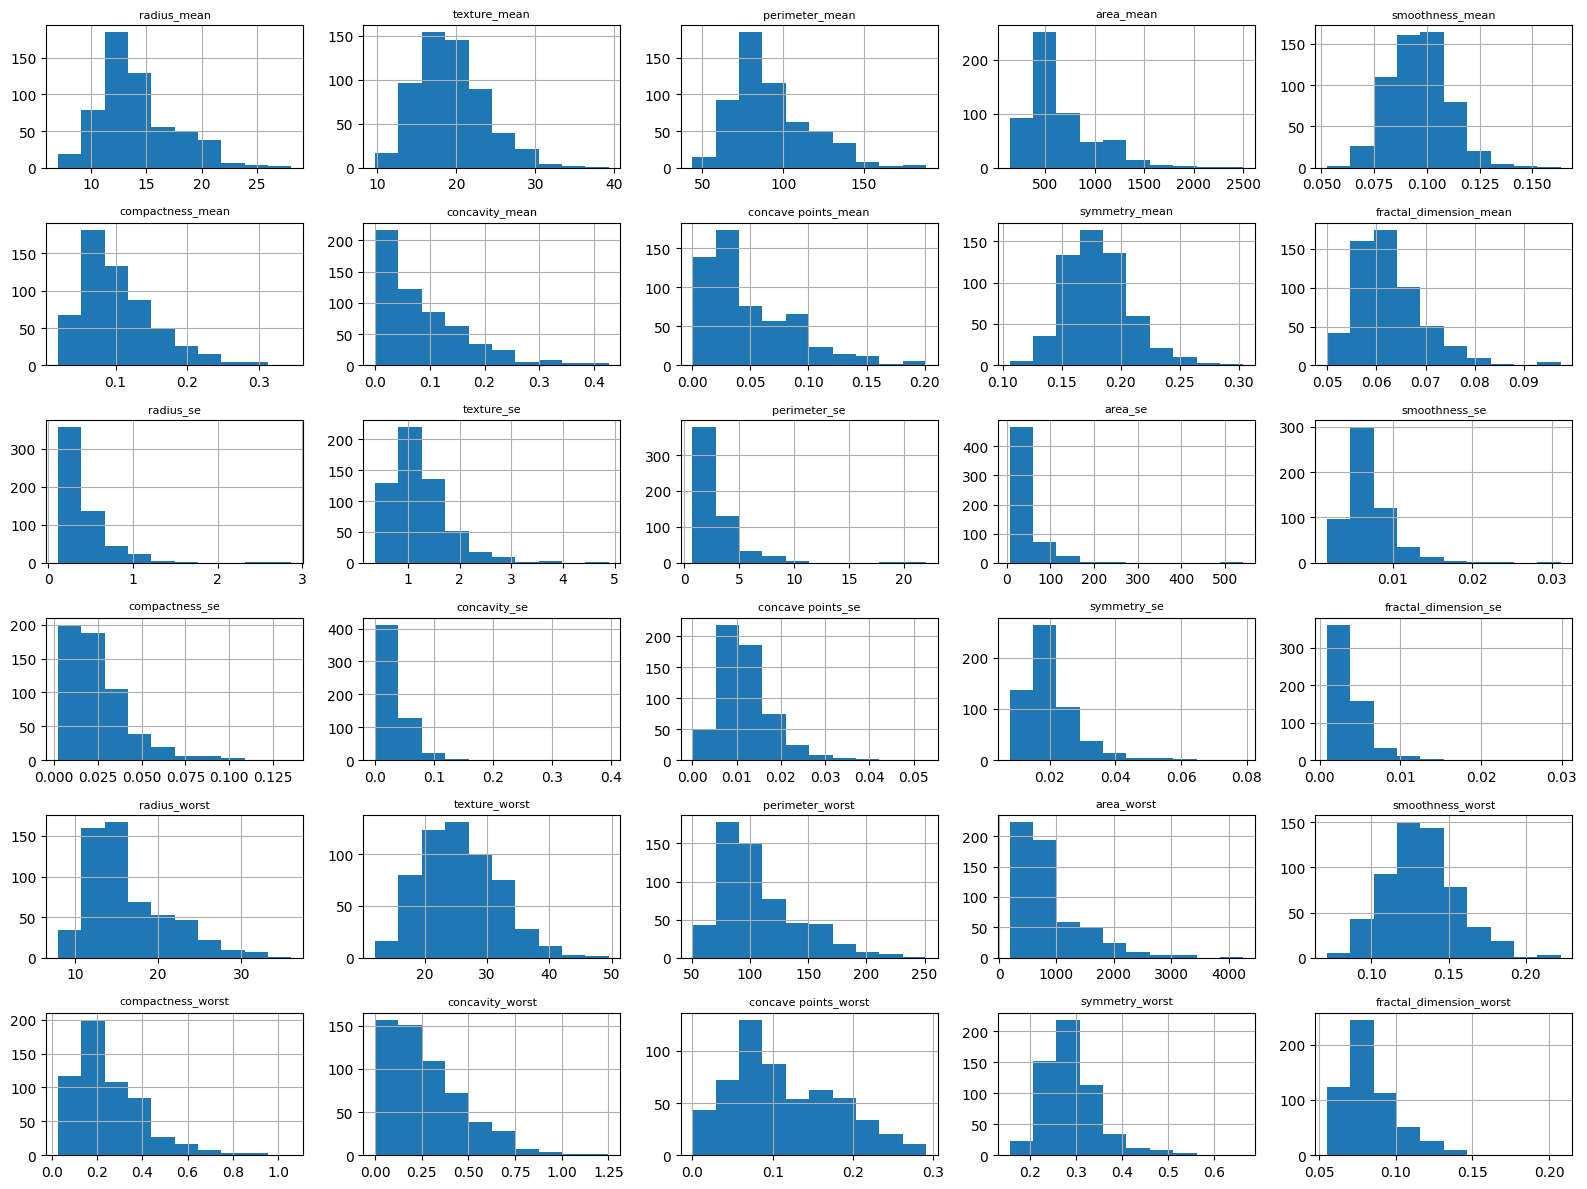

In [ ]:
plot_histograms(cancer_data)

None of the attributes appear to require special treatment. All follow a unimodal distribution with either a normal or positive-skewed distribution. Scaling later ought to account for these distributions, so no preprocessing need be done now.

# Part 2
Analyze and discuss the relationships between the data attributes and between the data attributes and labels. This involves computing the Pearson Correlation Coefficient (PCC) and generating scatter plots. [3 points]

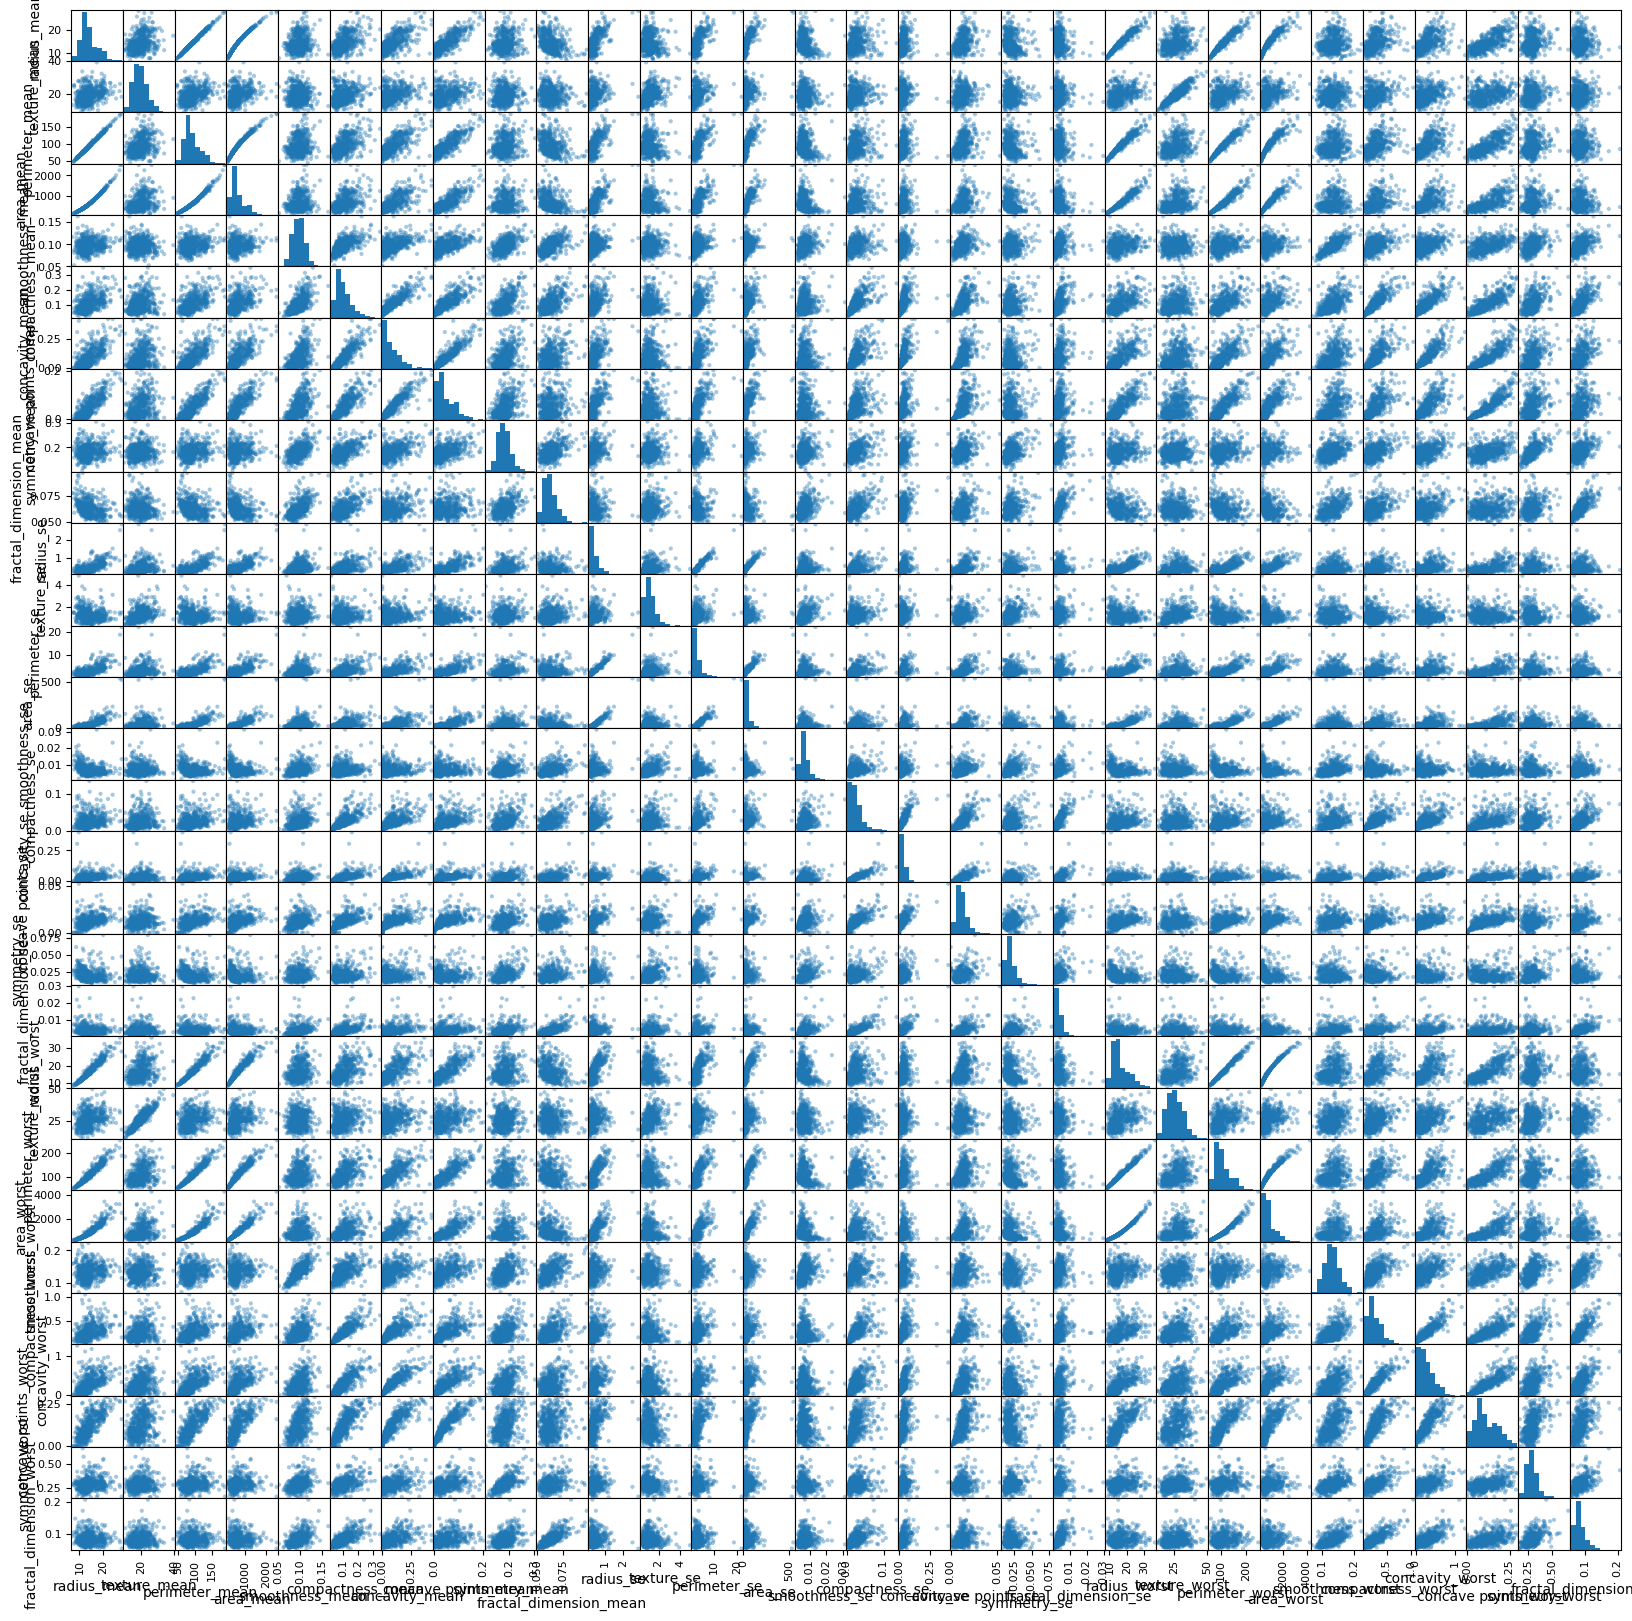

In [ ]:
pd.plotting.scatter_matrix(cancer_data, alpha=0.4, figsize=(20, 20));

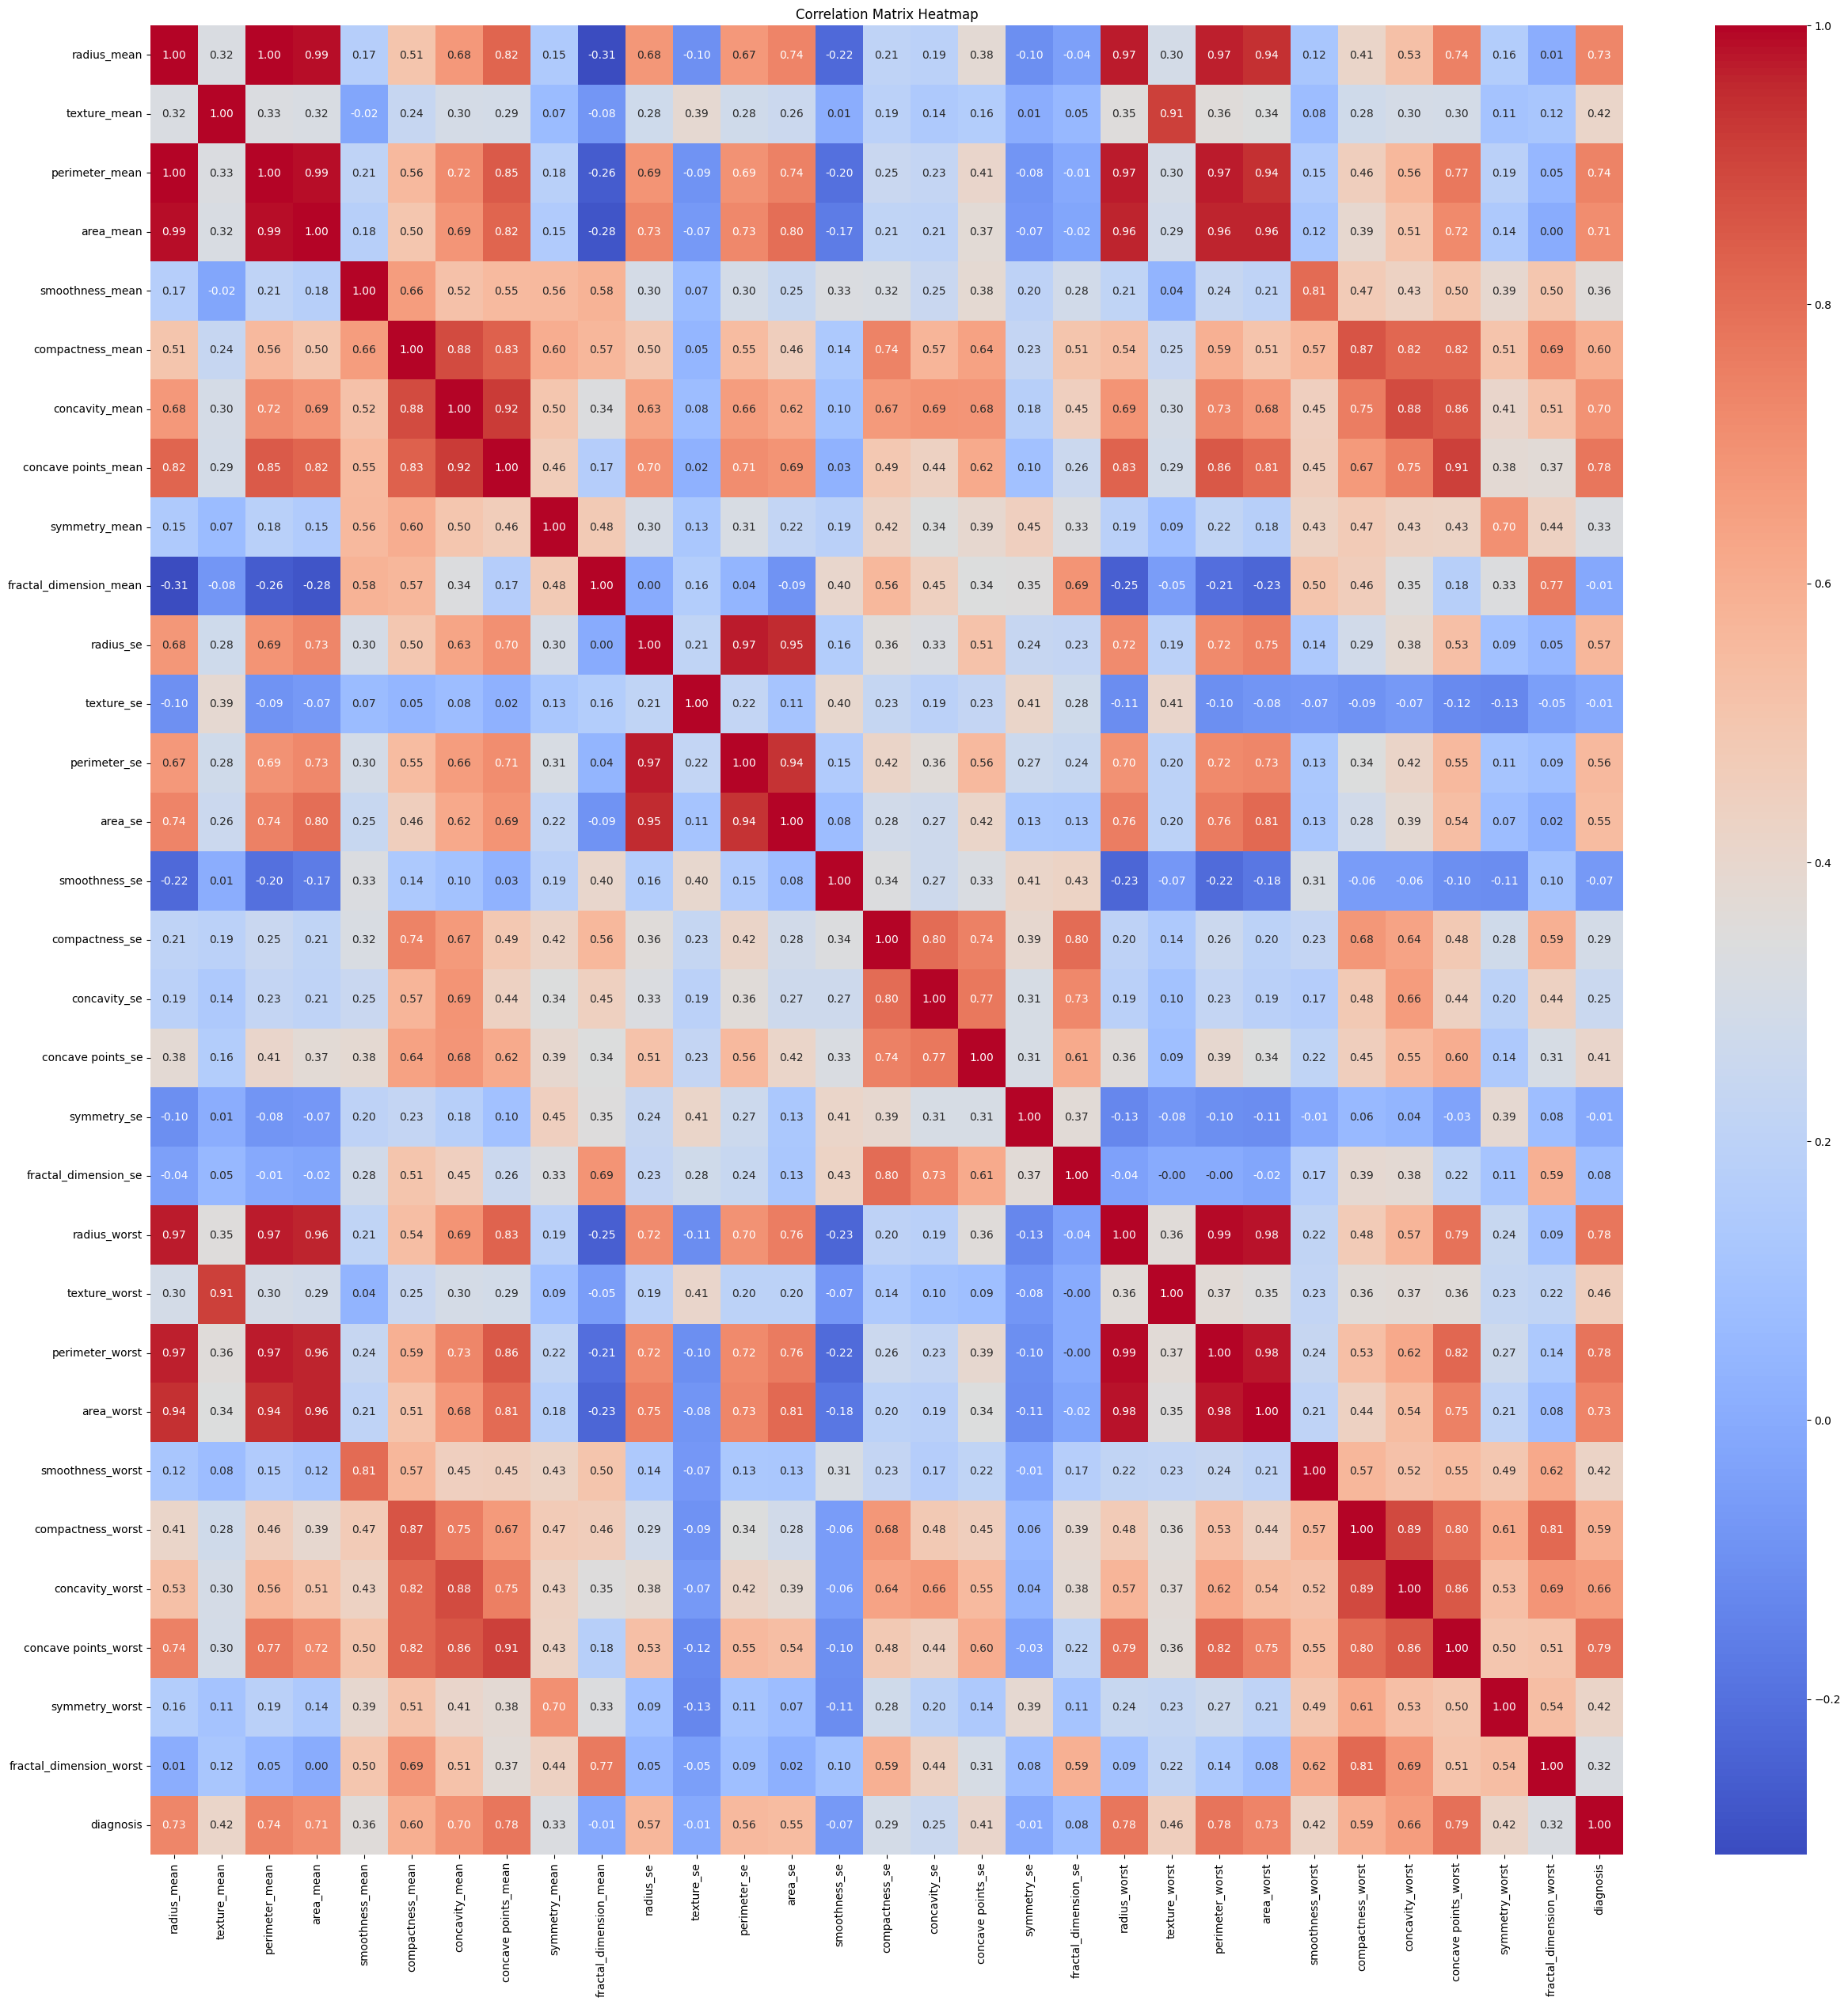

In [ ]:
plt.figure(figsize=(30, 30))
temp = cancer_data.copy()
temp.insert(len(temp.columns),"diagnosis", cancer_labels)
sns.heatmap(temp.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

There appears to be a strong correlation between several of the features. However, looking at the labels in the heatmap, this makes sense. Some features are measuring close approximations of the same thing, such as tumor size in the forms of both area, perimeter, and radius.

Several of the features have a strong correlation (>0.7) with the diagnosis, with *concave points_worst* being the highest at 0.79

# Part 3

In [ ]:
def train_val_test_split(data, labels, train_ratio = 0.8, test_val_ratio=0.5):
  train_data, x_temp, train_labels, y_temp = train_test_split(
      data, labels, test_size=(1-train_ratio), random_state=SEED
  )
  test_data, val_data, test_labels, val_labels = train_test_split(
      x_temp, y_temp, test_size=test_val_ratio, random_state=SEED
  )

  return train_data, train_labels, val_data, val_labels, test_data, test_labels

In [ ]:
train_data, train_labels, val_data, val_labels, test_data, test_labels = train_val_test_split(cancer_data, cancer_labels)

# Part 4
Train different classifiers and tweak the hyperparameters to improve performance (you can use the grid search if you want or manually try different values). Report training, validation and testing performance (classification accuracy, precision, recall and F1 score) and discuss the impact of the hyperparameters (use markdown cells in Jupyter Notebook to clearly indicate each solution):

In [ ]:
# Scales data such that x̄ = 0, σ = 1 using StandardScaler
def scale_data(X_train, X_test):
  scaler = StandardScaler()
  scaler.fit(X_train)

  X_train_scaled = scaler.transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # convert back to pd DF and keep the feature names and row indices
  X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
  X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
  return X_train_scaled, X_test_scaled

In [ ]:
train_data_scaled, val_data_scaled = scale_data(train_data, val_data)

In [ ]:
train_data_scaled.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
110,-1.219466,-0.501941,-1.196446,-1.016446,0.508206,-0.371103,-0.561434,-0.789281,-0.814729,1.118811,...,-1.061418,-0.647457,-1.039287,-0.882043,0.633372,-0.476320,-0.673113,-0.910891,-0.571615,0.074230
302,1.692285,1.104515,1.756091,1.666988,0.809996,1.502189,1.704390,2.019405,1.548647,1.696609,...,1.540492,0.658513,1.537128,1.427414,0.116402,0.587116,1.095205,1.205925,0.642743,0.657352
223,0.466939,0.260365,0.443398,0.304798,0.423986,0.311665,0.312750,0.404322,0.432707,0.029003,...,0.691730,0.799610,0.564170,0.370868,0.999560,1.299343,0.629756,0.529568,1.758165,1.339506
352,3.284672,-0.392038,3.371399,3.806892,1.294265,2.488032,3.033552,3.632450,0.507340,-0.231292,...,3.487290,-0.301277,3.622037,4.100059,0.904782,2.252249,1.834764,2.474857,1.274656,0.276371
257,0.345533,-0.436467,0.467935,0.170177,2.599683,2.339686,1.906520,1.922571,2.078185,1.878243,...,0.314731,-0.452218,0.383774,0.094220,1.917183,1.314385,0.850309,1.672064,0.585296,2.079331


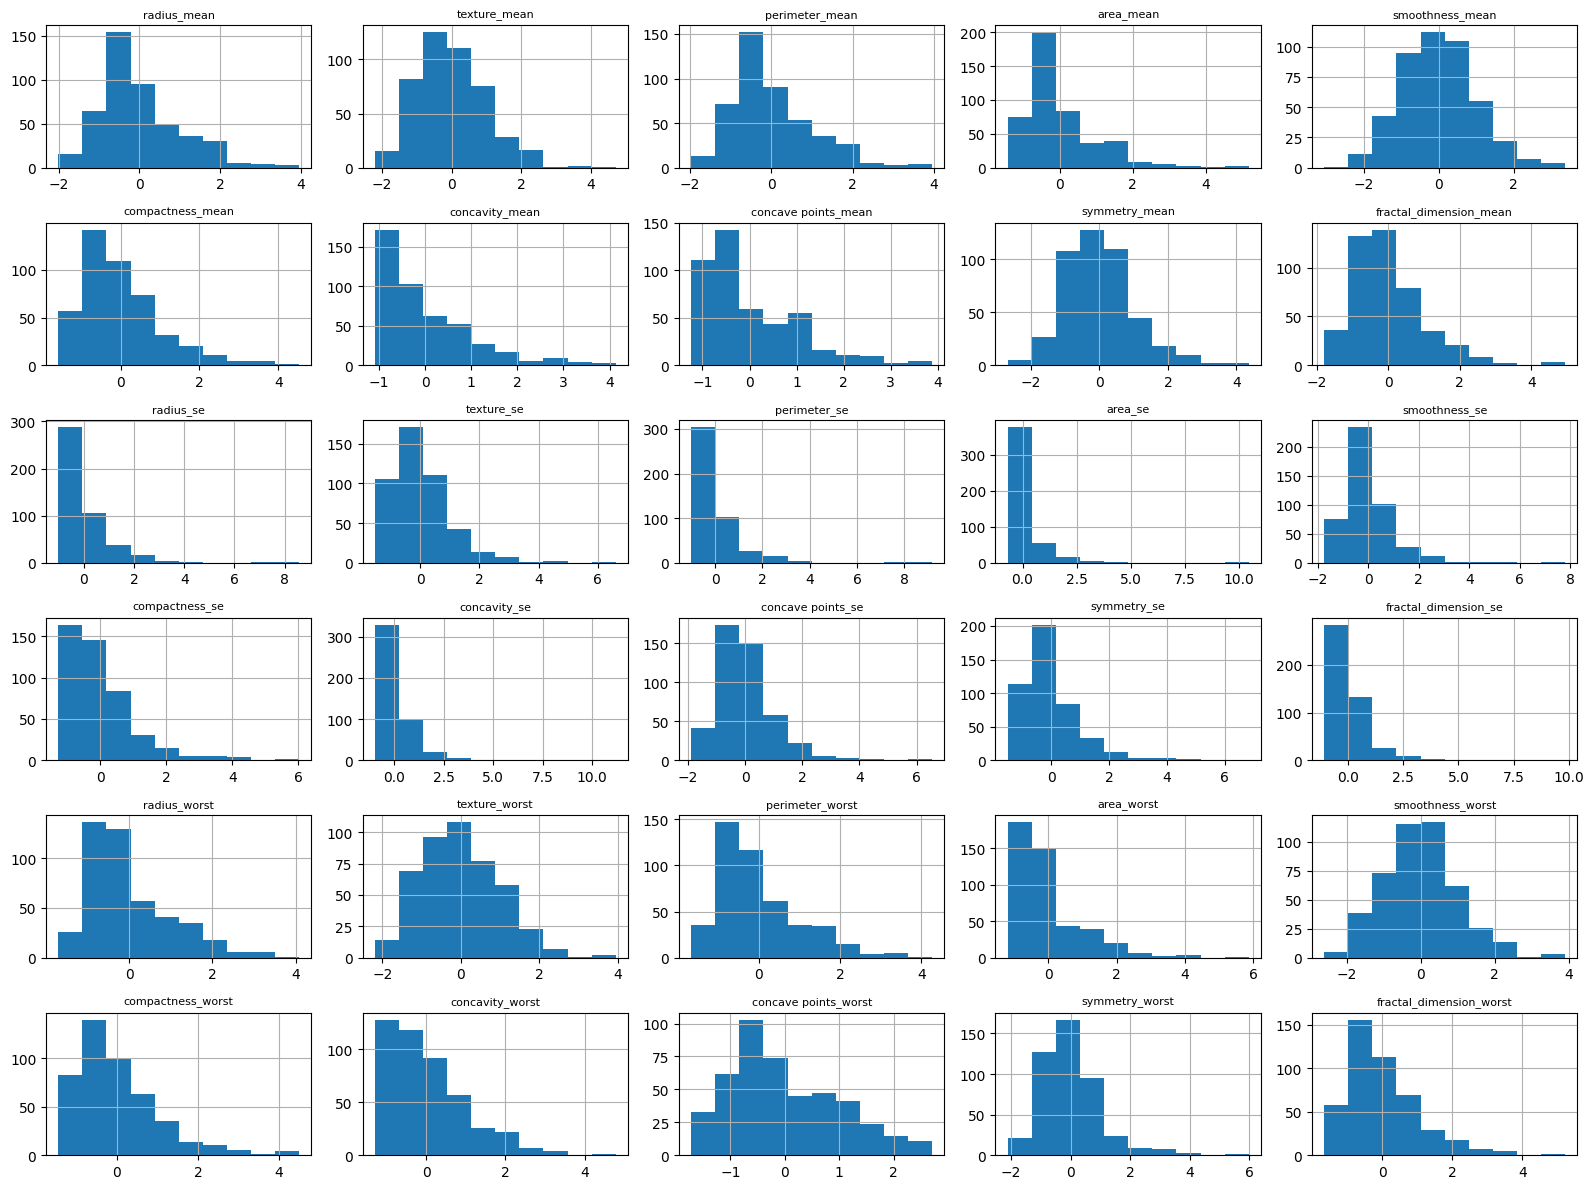

In [ ]:
plot_histograms(train_data_scaled)

In [ ]:
def run_model(model):
  model.fit(train_data_scaled, train_labels)
  y_pred = model.predict(val_data_scaled)
  rmse = root_mean_squared_error(val_labels, y_pred)
  print(f"The model's RMSE is {rmse:,.4f}")

In [ ]:
def print_model_results(model_data):
  min = model_data.loc[model_data["RMSE"].idxmin()]
  max = model_data.loc[model_data["RMSE"].idxmax()]
  print(f"Minimum RMSE Hyperparameters:\n{min}\n\nMaximum RMSE Hyperparameters:\n{max}")

In [ ]:
def test_model(model, name="classifier"):
  train_scaled, test_scaled = scale_data(train_data.iloc[:,1:], test_data.iloc[:,1:])
  model.fit(train_scaled, train_labels)
  y_pred = model.predict(test_scaled)

  test_rmse = root_mean_squared_error(test_labels, y_pred)
  accuracy = accuracy_score(test_labels, y_pred)
  precision = precision_score(test_labels, y_pred, average='weighted')
  recall = recall_score(test_labels, y_pred, average='weighted')
  f1 = f1_score(test_labels, y_pred, average='weighted')

  print(f"Model:\t{name}")
  print(f"Test RMSE:\t{test_rmse:,.4f}")
  print(f"Accuracy:\t{accuracy:,.4f}")
  print(f"Precision:\t{precision:,.4f}")
  print(f"Recall:\t\t{recall:,.4f}")
  print(f"F1 Score:\t{f1:,.4f}")
  print()

## Logistic Regression
Hyperparameters to explore: C, solver, max number of iterations. [10 points]

### Base Model

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 455 entries, 110 to 228
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              455 non-null    float64
 1   texture_mean             455 non-null    float64
 2   perimeter_mean           455 non-null    float64
 3   area_mean                455 non-null    float64
 4   smoothness_mean          455 non-null    float64
 5   compactness_mean         455 non-null    float64
 6   concavity_mean           455 non-null    float64
 7   concave points_mean      455 non-null    float64
 8   symmetry_mean            455 non-null    float64
 9   fractal_dimension_mean   455 non-null    float64
 10  radius_se                455 non-null    float64
 11  texture_se               455 non-null    float64
 12  perimeter_se             455 non-null    float64
 13  area_se                  455 non-null    float64
 14  smoothness_se            455 

In [ ]:
def lr_model(max_iter = 1000, solver="liblinear", C=1.0):
   return(LogisticRegression(
       random_state=SEED,
       max_iter=max_iter,
       solver=solver,
       C=C,
   ))

run_model(lr_model())

The model's RMSE is 0.2294


### Hyperparameter Tuning
Iteration on all parameters, with minimum RMSE used for testing

In [ ]:
def lr_hyperparameter_tuning(
  iterations = [100,1000,5000,10000],
  solvers = ["lbfgs", "liblinear", "sag", "saga"],
  Cs = [0.01, 0.1, 1, 10, 100]):

  data = pd.DataFrame(columns=["Iteration", "Solver", "C", "RMSE"])

  index = 0
  for i in iterations:
    for s in solvers:
      for c in Cs:
        model = lr_model(max_iter=i, solver=s, C=c)
        model.fit(train_data_scaled, train_labels)
        y_pred = model.predict(val_data_scaled)
        rmse = root_mean_squared_error(val_labels, y_pred)

        data.loc[index] = [i, s, c, rmse]
        index += 1

  return data


In [ ]:
lr_hp_data = lr_hyperparameter_tuning()
# print(tabulate(lr_hp_data, headers = ["Iterations", "Solver", "C-Value", "RMSE"]))

In [ ]:
print_model_results(lr_hp_data)

Minimum RMSE Hyperparameters:
Iteration          100
Solver       liblinear
C                  0.1
RMSE          0.132453
Name: 6, dtype: object

Maximum RMSE Hyperparameters:
Iteration         100
Solver          lbfgs
C                0.01
RMSE         0.296174
Name: 0, dtype: object


Seeing as 100 iterations was producing the min and max RMSE, I will experiment with even fewer iterations.

In [ ]:
lr_hp_data = lr_hyperparameter_tuning(iterations = [10, 50, 100], solvers = ["lbfgs"], Cs = [0.1])

In [ ]:
print_model_results(lr_hp_data)

Minimum RMSE Hyperparameters:
Iteration          10
Solver          lbfgs
C                 0.1
RMSE         0.187317
Name: 0, dtype: object

Maximum RMSE Hyperparameters:
Iteration          10
Solver          lbfgs
C                 0.1
RMSE         0.187317
Name: 0, dtype: object


As in Question 1, performance hasn't improved, implying it reached a stable minimum quite quickly. I will leave it's parameters here for the prime model.

In [ ]:
prime_lr_model = lr_model(max_iter=10, solver="lbfgs", C=0.1)

## Support Vector Machine (make sure to try using kernels)
Hyperparameters to explore: C, kernel, degree of polynomial kernel, gamma.  [10 points]

### Base Model

In [ ]:
# Define SVM classifier
def svm_model(C=1.0, kernel='rbf', degree=3, gamma='scale'):
  return SVC(kernel=kernel, C=C, gamma=gamma, degree=degree, random_state=SEED, probability=True)

run_model(svm_model())

The model's RMSE is 0.1325


### Hyperparameter Tuning

In [ ]:
def svm_hyperparameter_tuning(
  Cs = [0.01, 0.1, 1, 10, 100],
  kernels = ['linear', 'poly', 'rbf', 'sigmoid'],
  degrees = [3,4,5],
  gammas = [0.01, 0.1, 1, 10, 'scale']):

  data = pd.DataFrame(columns=["C", "Kernel", "Degree", "Gamma", "RMSE"])

  index = 0
  for c in Cs:
    for k in kernels:
      for d in degrees:
        for g in gammas:
          model = svm_model(C=c, kernel=k, degree=d, gamma=g)
          model.fit(train_data_scaled, train_labels)
          y_pred = model.predict(val_data_scaled)
          rmse = root_mean_squared_error(val_labels, y_pred)

          data.loc[index] = [c, k, d, g, rmse]
          index += 1

  return data

In [ ]:
svm_hp_data = svm_hyperparameter_tuning()

In [ ]:
# print(tabulate(svm_hp_data, headers = ["C-Value", "Kernel", "Degrees", "Gamma", "RMSE"]))

In [ ]:
print_model_results(svm_hp_data)

Minimum RMSE Hyperparameters:
C              1.0
Kernel         rbf
Degree           3
Gamma          0.1
RMSE      0.132453
Name: 151, dtype: object

Maximum RMSE Hyperparameters:
C             0.01
Kernel        poly
Degree           3
Gamma         0.01
RMSE      0.662266
Name: 15, dtype: object


There does not appear to be further tuning that can be done on the SVM model, so the ideal values from this hyperparameter tuning will be used.

In [ ]:
prime_svm_model = svm_model(C=1.0, kernel='rbf', degree=3, gamma=0.1)

## Random Forest Classifier (also analyze feature importance)
Hyperparameters to explore: the number of trees, max depth, the minimum number of samples required to split an internal node, the minimum number of samples required to be at a leaf node. [10 points]

### Base Model

In [ ]:
def rf_model(n=100, max_depth=None, min_samples_split=2, min_samples_leaf=1):
  return RandomForestClassifier(
      n_estimators=n,
      max_depth=max_depth,
      min_samples_split=min_samples_split,
      min_samples_leaf=min_samples_leaf,
      random_state=SEED
  )

run_model(rf_model())

The model's RMSE is 0.1873


### Hyperparameter Tuning

In [ ]:
def rf_hyperparameter_tuning(
  tree_count = [50, 75, 100, 200],
  max_depths = [5, 10, 15, None],
  min_samples_splits = [2, 5, 10],
  min_samples_leafs = [1, 2, 4, 8]):

  data = pd.DataFrame(columns=["Tree.Count", "Max.Depth", "Min.Samples.per.Split", "Min.Samples.per.Leaf", "RMSE"])

  index = 0
  for t in tree_count:
    for d in max_depths:
      for s in min_samples_splits:
        for l in min_samples_leafs:
          model = rf_model(n = t,
                           max_depth = d,
                           min_samples_split = s,
                           min_samples_leaf = l)

          model.fit(train_data_scaled, train_labels)
          y_pred = model.predict(val_data_scaled)
          rmse = root_mean_squared_error(val_labels, y_pred)

          data.loc[index] = [t, d, s, l, rmse]
          index += 1

  return data

In [ ]:
rf_hp_data = rf_hyperparameter_tuning()

In [ ]:
print_model_results(rf_hp_data)

Minimum RMSE Hyperparameters:
Tree.Count               50.000000
Max.Depth                 5.000000
Min.Samples.per.Split     2.000000
Min.Samples.per.Leaf      2.000000
RMSE                      0.187317
Name: 1, dtype: float64

Maximum RMSE Hyperparameters:
Tree.Count               50.000000
Max.Depth                 5.000000
Min.Samples.per.Split     2.000000
Min.Samples.per.Leaf      4.000000
RMSE                      0.264906
Name: 2, dtype: float64


There does not appear to be further tuning that can be done on the Random Forest model, so the ideal values from this hyperparameter tuning will be used.

In [ ]:
prime_rf_model = rf_model(n=50, max_depth=5, min_samples_split=2, min_samples_leaf=2)

In [ ]:
feature_imp = (prime_rf_model.fit(train_data_scaled, train_labels)).feature_importances_
ranked = list(reversed(np.argsort(feature_imp)))
print("The three most important features were:\n")
for i in range(3):
  print(f"{i+1}. {cancer_data.columns[ranked[i]]}: {feature_imp[ranked[i]]:,.4f}")

The three most important features were:

1. radius_worst: 0.1904
2. perimeter_worst: 0.1523
3. concave points_worst: 0.1331


These correspond to the strongest correlations with the target label which is not surprising.

# Part 5
Combine your classifiers into an ensemble and try to outperform each individual classifier on the validation set. Once you have found a good one, try it on the test set. Describe and discuss your findings. [8 points]

## Hard Classifier Ensemble

In [ ]:
hard_voting_model = VotingClassifier(
    estimators=[('lr', prime_lr_model), ('svc', prime_svm_model), ('rf', prime_rf_model)],
    voting='hard'   # 'hard' uses majority vote, 'soft' uses probabilities
)

As a refresher, here are the results for the prime models.

In [ ]:
run_model(prime_lr_model)
run_model(prime_svm_model)
run_model(prime_rf_model)

The model's RMSE is 0.1873
The model's RMSE is 0.1325
The model's RMSE is 0.1873


The ensemble method

In [ ]:
run_model(hard_voting_model)

The model's RMSE is 0.0000


Frankly, I am surprised at the RMSE of the ensemble. Somehow, it is mapping perfectly which I am skeptical of. However, since each individual model has error and this is using Hard Voting, I do not see how it could be itself overfitting.

In [ ]:
test_model(hard_voting_model, name = "Ensemble")

Model:	Ensemble
Test RMSE:	0.1873
Accuracy:	0.9649
Precision:	0.9670
Recall:		0.9649
F1 Score:	0.9648



In [ ]:
test_model(prime_lr_model, name = "Logistic Regression")
print()
test_model(prime_svm_model, name = "Support Vector Machine")
print()
test_model(prime_rf_model, name = "Random Forest")

Model:	Logistic Regression
Test RMSE:	0.1873
Accuracy:	0.9649
Precision:	0.9670
Recall:		0.9649
F1 Score:	0.9648


Model:	Support Vector Machine
Test RMSE:	0.2294
Accuracy:	0.9474
Precision:	0.9478
Recall:		0.9474
F1 Score:	0.9473


Model:	Random Forest
Test RMSE:	0.1325
Accuracy:	0.9825
Precision:	0.9830
Recall:		0.9825
F1 Score:	0.9824



I am even more skeptical since the has the exact same statistical values as the Logistic Regression here. However, curiously, the RMSE still differed on validation.

In [ ]:
print(f"The average RMSE of the indiviudal models is {np.average([0.1873, 0.2294, 0.1325]):,.4f}")

The average RMSE of the indiviudal models is 0.1831


## Soft Classifier Ensemble

In [ ]:
soft_voting_model = VotingClassifier(
    estimators=[('lr', prime_lr_model), ('svc', prime_svm_model), ('rf', prime_rf_model)],
    voting='soft'   # 'hard' uses majority vote, 'soft' uses probabilities
)

In [ ]:
run_model(soft_voting_model)

The model's RMSE is 0.0000


In [ ]:
test_model(soft_voting_model)

Model:	classifier
Test RMSE:	0.1873
Accuracy:	0.9649
Precision:	0.9670
Recall:		0.9649
F1 Score:	0.9648



Again, the Soft Voting Model also has identical performance to the Linear Regression model with the caveats above.

After examining the code, the training, validation, and testing sets appear to be properly divided. And considering that the ensemble method is in-built using VotingClassifier(), I do not see where I could have introduced a bug. So, ensemble, at least in training, seems to be remarkably effective. And yet, in testing, it is effectively performing in line with Logistic Regression.

However, the random forest is far and away the best model, scoring best in all metrics. It's high recall AND precision is especially noteworthy given this is a medical diagnosis training set. It is catching the malignant tumors with a relatively small amount of false positives.

# References

This assignment largely built on Homework 1. I referred to Scikit-learn's documentation for the new model methods. However, I relied heavily on ChatGPT for creating the plots. After fooling around with R so much last time, I will try and study the code generated here to be able to create it myself on the next Homework.